**NLP?**
Is a field that combines linguistics and AI to enable computers to process and understand human language.

**SECTION 1: NLP Flow / BluePrint**

1. **Import the Libraries/Modules**
* Purpose: Import the important libraries that will help to accomplish the goal
* Key term:
    * Module: a library of important code that you can reuse in other programs.

2. **Data Collection, Cleaning, and Exploraion**
* Purpose: Get the data (e.g., SMS messages).
* Key term:
    * Dataset: A collection of data.

3. **Text Cleaning (Normalization)**
* Purpose: Make text consistent and remove unnecessary variation.
* What we do:
    * Convert all text to Lowercase text ("Hello" → "hello")
    * Remove punctuation
* Key terms:
    * Normalization: Making text uniform so the model doesn’t treat similar things differently.

4. **Tokenization**
* Purpose: Break text into smaller pieces (words).
    * Example:
        "I love AI" → ["I", "love", "AI"]
* Key term: 
    * Token: A single unit (usually a word).

5. **Stop Words Removal**
* Purpose: Remove common words that don’t add much meaning.
    * Example: "the", "is", "and"
* Key term:
    * Stop words: Frequently used words that carry little useful information.

6. **Stemming / Lemmatization** 
* Purpose: Reduce words to their base form.
    * Example:
        * Stemming: "running" → "run"
        * Lemmatization: "better" → "good"
* Key terms:
    * Stem: Crude root form of a word
    * Lemma: Proper dictionary form of a word

7. **Vectorization**
* Purpose: Convert text into numbers so a model can understand it.
    * Example:
        "love AI" → [0,1,1,0]
* Key terms:
    * Vector: A list of numbers
    * Bag of Words: Count of words, ignoring order
    * Feature: A word used as input to the model

8. **Model Training**
* Purpose: Teach a machine learning model to recognize patterns.
    * Example: Learn what spam messages look like.
* Key terms:
    * Model: A function that learns from data
    * Training: The process of learning patterns

9. **Prediction / Evaluation**
* Purpose: Test how well the model performs.
    * Example: Predict if a new SMS is spam or ham.
* Key terms:
    * Prediction: Model output
    * Accuracy: How often the model is correct

### 1. Import the Libraries / Modules, that will help achieve the desired goal

In [2]:
# import the base libraries for loading data and visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#view the graphs inline
%matplotlib inline              

# import the NLTK library and useful functions
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

# import the sklearn functions useful for NLP
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score



#### 2. Data Collection And Exploration

In [3]:
# Load the data
sms_data = pd.read_csv('../datasets/spam.csv', encoding='latin-1')

In [3]:
# View the first 5 columns
sms_data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


**Observations**
The data has the label column named as v1 and the features column as v2. The rest of the columns will not contribute mutch to our goal as they are unnamed and seem to contain missing values (more on this later)

Lets explore the data next (Note: in the future, use the info() function to get the data info all at once))


In [ ]:
# View the shape of the data -> total rows and columns i.e, (rows, columns)
print("The summary of the data is as follows:", "\n",
         sms_data.info(), "\n", "The shape of the data is: ", sms_data.shape, "\n", 
      "The total missing values per column is: ", sms_data.isna().sum(), "\n",
       "The data types for each column","\n", 
       sms_data.dtypes, "\n"
        )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   int64 
 1   message  5572 non-null   object
dtypes: int64(1), object(1)
memory usage: 87.2+ KB
The summary of the data is as follows: 
 None 
 The shape of the data is:  (5572, 2) 
 The total missing values per column is:  label      0
message    0
dtype: int64 
 The data types for each column 
 label       int64
message    object
dtype: object 
 Check for duplicates:  403


#

In the future, use the info() function to get the summary as quickly as possible

* The Unnamed columns have many missing values and will not contribute to the goal of this project and will be removed. V2 and v1 columns have no missing values and will be kept.

In [4]:
# remove the unneccesary columns and rename the remaining columns to something meaningful
sms_data = sms_data[['v1', 'v2']]
sms_data.columns = ['label', 'message']
sms_data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Since our goal is to classify the messages, lets convert the labels: ham = 0 and spam = 1 

In [5]:
# convert the label column to binary values
sms_data['label'] = sms_data['label'].map({'ham': 0, 'spam': 1})
# verify
sms_data.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
#Check for number of dupplicates
print("Number of duplicates: ", sms_data.duplicated().sum())

# View the top 10 duplicates, sort them so that duplicates are together. Note "keep=False" -
# makes sure we return both the 1st and 2nd duplicate. 
sms_data[sms_data['message'].duplicated(keep=False)].sort_values(by='message').head(10)


Number of duplicates:  403


,label,message
504,1,+123 Congratulations - in this week's competit...
2123,1,+123 Congratulations - in this week's competit...
2343,0,1) Go to write msg 2) Put on Dictionary mode 3...
1372,0,1) Go to write msg 2) Put on Dictionary mode 3...
2162,0,1) Go to write msg 2) Put on Dictionary mode 3...
1049,1,18 days to Euro2004 kickoff! U will be kept in...
2718,1,18 days to Euro2004 kickoff! U will be kept in...
2043,1,4mths half price Orange line rental & latest c...
388,1,4mths half price Orange line rental & latest c...
1778,0,7 wonders in My WORLD 7th You 6th Ur style 5th...


**Dealing with Duplicates**
* Impact of duplicates on the goal: 
* Resolution: 

In [6]:
# Remove the duplicates 
sms_data = sms_data.drop_duplicates()

#verify the removal
sms_data[sms_data['message'].duplicated(keep=False)].sort_values(by='message').head(10)


,label,message


The count of Spam and ham rows from the data
label
0    4516
1     653
Name: count, dtype: int64


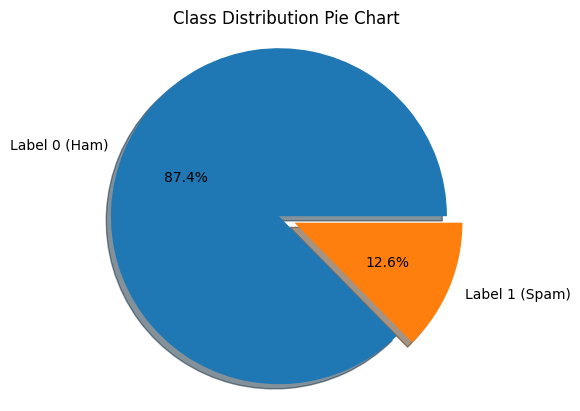

In [8]:
#Check the class Distribution -> Check the data balance, you dont want 
# a certain feature to have more examples than the other as this will cause
# the model to learn those features only. 
print("The count of Spam and ham rows from the data")
print(sms_data['label'].value_counts())

# make sense of the info in a pie chart
explode = (0.1,0)
plt.pie(sms_data['label'].value_counts(), explode = explode,
        labels=['Label 0 (Ham)', 'Label 1 (Spam)'], 
        autopct='%1.1f%%', shadow=True)
plt.axis('equal')
plt.title("Class Distribution Pie Chart")
plt.show()


From the class distribution, we have roughly 87% ham and 13%spam. If we continue with the data as it is, it will influence the model to overfit the data, and especially when it comes to detecting spam -- as there isn't enough examples for spam especially when we will split the data for training and testing. 
* Imbalance means the model sees one class much more, it becomes biased toward it.

There are some techniques we can employ to address the issue which fall into two stages, Pre-Training and Post-Training:
* Pre-Training: This is where we deal with the issue before training the model using techniques such as oversampling.
    * **Oversampling** - the idea is to duplicate the imbalanced variable (spam messages) to balance the data.
    * **Undersampling** - downsize the other variable(s) (ham messages) to match the imbalanced one
    * Apply the **SMOTE** technique - this technique helps us with generating synthetic examples(data) for the imbalanced data. This technique is *applied after splitting the data into training and test set*. SMOTE creates new minority samples by interpolating between similar existing ones, not by copying, hence it can work but is not always ideal for NLP, because SMOTE works best with continuous numeric data, NLP vectors are sparse and discrete.
    * Use **Class Weights**: Simply tell the model which variable is more important. Note that Naive Bayes doesnt directly support class weights, but other models do.
    * Apply a **Text Augmentation Technique**: With help from libraries such as nlpaug, EDA, and TextAttack, to name a few, we can augment the data. So instead of duplicating or reducing the data, or creating fake numeric vectors, we create new text samples by slightly modifying real text. 
        * Consider the sentence "win a free prize now". It can be augmented into one of the following: "win a free reward now", "get a free prize now", and "win a free prize today".
        * Augmentation techniques include synonym replacement, contextual augmentation, random insertion, random swap, and random deletion to name a few.
* Post-Training: This is where we deal with the issue after or during the training of the model using better evaluation metrics.
    * Precision → “When I predict spam, how often am I right?”
    * Recall → “How many spam messages did I catch?”
    * F1-score → Balance of both -> did I classify both spam and ham correctly?

All these methods for dealing with the imbalanced data can be explored and one can determine how they impact the model's performance. I will proceed with the nlpaug library to generate meaningful data with real sentences by applying contextual augmentation to take advantage of the recent powerful tech -- Why not?!


In [1]:
# import the nlpaug contextual augmenter
import nlpaug.augmenter.word as naw

c:\Users\Isaac Maake\Documents\Projects\AIE\Data-Science-AI-ML-\NLP\nlpEnv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# initialize the augmenter. We will use the bert-based-uncased pre-trained model
# to replace(substitute) words
aug = naw.ContextualWordEmbsAug(model_path='bert-base-uncased', action='substitute')

c:\Users\Isaac Maake\Documents\Projects\AIE\Data-Science-AI-ML-\NLP\nlpEnv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\Isaac Maake\Documents\Projects\AIE\Data-Science-AI-ML-\NLP\nlpEnv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Isaac Maake\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks o

In [ ]:
# apply to 